Transformacion Hit-or-Miss

La transformación hit-or-miss es una operación morfológica que permite detectar la presencia o ausencia de un patrón específico en una imagen binaria.

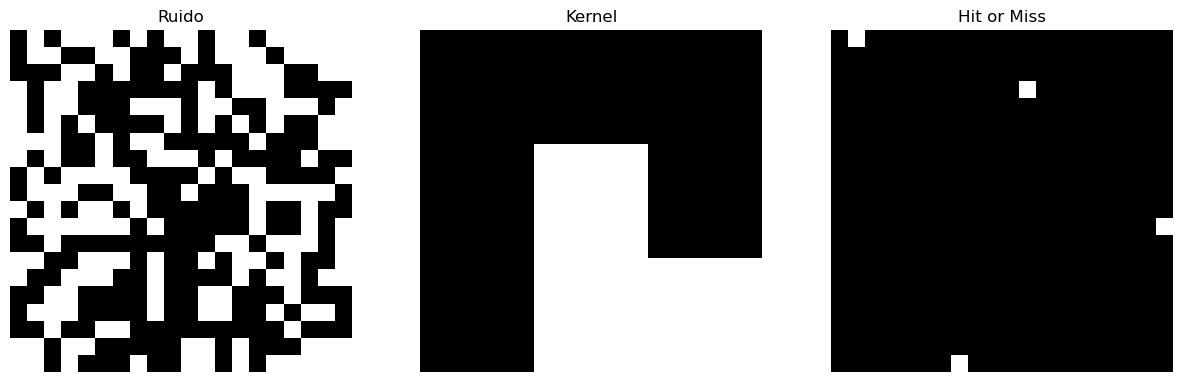

In [170]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from skimage import morphology

ruido = np.random.randint(0, 2, (20, 20), dtype=np.uint8)
kernel = np.array([[-1, -1, -1],
                   [-1,  1, -1],
                   [-1,  1,  1]])

hitormiss = cv2.morphologyEx(ruido, cv2.MORPH_HITMISS, kernel)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(ruido, cmap='gray')
plt.title('Ruido')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel, cmap='gray')
plt.title('Kernel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hitormiss, cmap='gray')
plt.title('Hit or Miss')
plt.axis('off')
plt.show()

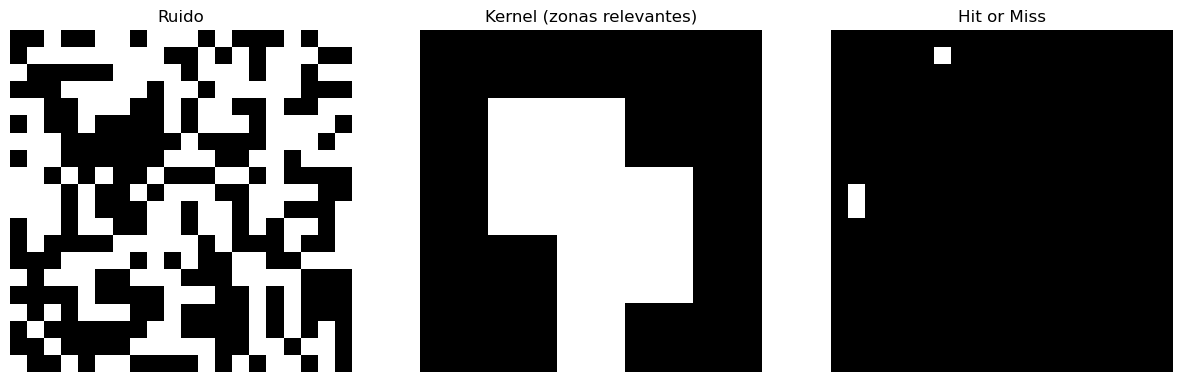

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion

ruido = np.random.randint(0, 2, (20, 20), dtype=np.uint8)

kernel = np.array([[-1, -1, -1, -1, -1],
                   [-1,  1,  1, -1, -1],
                   [-1,  1,  1,  1, -1],
                   [-1, -1,  1,  1, -1],
                   [-1, -1,  1, -1, -1]])

hit_mask = (kernel == 1)
miss_mask = (kernel == 0)

hit = binary_erosion(ruido, structure=hit_mask)
miss = binary_erosion(1 - ruido, structure=miss_mask)

hitormiss = hit & miss

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(ruido, cmap='gray')
plt.title('Ruido')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel != -1, cmap='gray')
plt.title('Kernel (zonas relevantes)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hitormiss, cmap='gray')
plt.title('Hit or Miss')
plt.axis('off')
plt.show()


Erosión y Dilatación geodésicas

Las erosión y dilatación geodésicas son variantes de las operaciones morfológicas clásicas, pero restringidas por una imagen de máscara.